# NLP on Brazilian E-Commerce Customer Reviews

**Internship Project — Natural Language Processing (NLP) on Text Data**

### Objective
Analyze customer review text from the Olist Brazilian e-commerce dataset using text preprocessing, tokenization, sentiment analysis, word-frequency analysis, and topic modeling. The project also visualizes the main patterns and converts them into practical insights.

### Dataset
The analysis uses `olist_order_reviews_dataset.csv` from the uploaded Olist dataset. The review text is in Portuguese, so Portuguese stopwords are used during preprocessing.

> **Sentiment methodology:** the dataset does not provide a separate NLP sentiment label. Therefore, `review_score` is converted into a transparent proxy label: 1–2 = Negative, 3 = Neutral, 4–5 = Positive. This is a labeled sentiment analysis based on the customer's rating, not an independent language-model sentiment prediction.

## 1. Setup and Imports

In [1]:
import os
import re
import unicodedata
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 110

# A compact Portuguese stopword list keeps the notebook self-contained.
pt_stopwords = set("a ao aos as de da das do dos e em no na nos nas um uma uns umas por para com sem que se sua suas seu seus foi sao ser era eu voce voces ele ela eles elas isso isto aquele aquela muito mais menos como mas ou ou porque quando onde ja nao sim tem tenho tinha pode podem pelo pela pelos pelas este esta estes estas meu minha meus minhas nosso nossa nossos nossas seu sua seus suas lhe lhes me te nos vos".split())

DATA_PATH = r"/mnt/data/olist_data/olist_order_reviews_dataset.csv"
OUTPUT_DIR = "visualizations"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 2. Load the Dataset

In [2]:
reviews = pd.read_csv(DATA_PATH)
print(f"Rows: {reviews.shape[0]:,}")
print(f"Columns: {reviews.shape[1]}")
print("\nColumns:", list(reviews.columns))
reviews.head()

Rows: 99,224
Columns: 7

Columns: ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


## 3. Data Exploration and Quality Checks

In [3]:
print("Data types:")
print(reviews.dtypes)

print("\nMissing values:")
missing = reviews.isna().sum().sort_values(ascending=False)
print(missing)

print("\nDuplicate rows:", reviews.duplicated().sum())
print("\nReview score distribution:")
print(reviews["review_score"].value_counts().sort_index())

Data types:
review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_date       object
review_answer_timestamp    object
dtype: object

Missing values:
review_comment_title       87656
review_comment_message     58247
review_id                      0
review_score                   0
order_id                       0
review_creation_date           0
review_answer_timestamp        0
dtype: int64



Duplicate rows: 0

Review score distribution:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


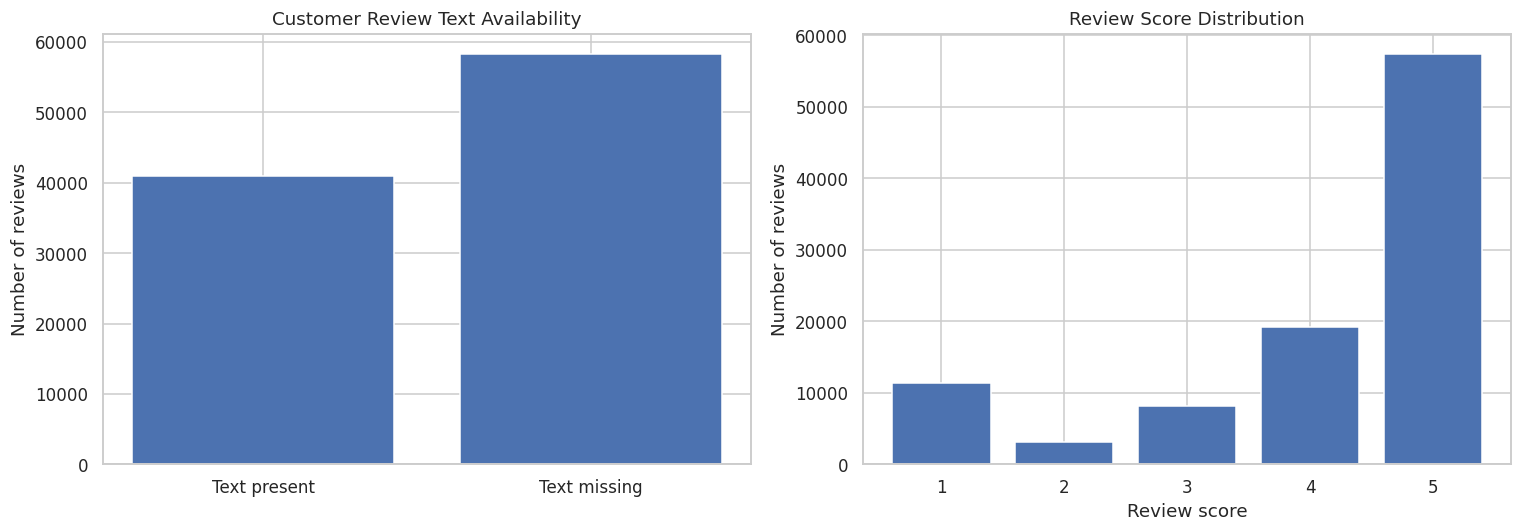

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missing review text
text_missing = reviews["review_comment_message"].isna().sum()
text_present = reviews["review_comment_message"].notna().sum()
axes[0].bar(["Text present", "Text missing"], [text_present, text_missing])
axes[0].set_title("Customer Review Text Availability")
axes[0].set_ylabel("Number of reviews")

# Score distribution
score_counts = reviews["review_score"].value_counts().sort_index()
axes[1].bar(score_counts.index.astype(str), score_counts.values)
axes[1].set_title("Review Score Distribution")
axes[1].set_xlabel("Review score")
axes[1].set_ylabel("Number of reviews")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_data_exploration.png", bbox_inches="tight")
plt.show()

### Initial data-quality observations

- The review table contains both structured ratings and free-text comments.
- A large number of reviews have no written comment, so text-based NLP must operate only on rows with usable review text.
- `review_score` is complete and can provide a transparent reference label for sentiment grouping.

## 4. Prepare the Text Corpus

In [5]:
# Keep rows with written review text. Combine title + message when available.
text_df = reviews.copy()
text_df["review_comment_title"] = text_df["review_comment_title"].fillna("")
text_df["review_comment_message"] = text_df["review_comment_message"].fillna("")
text_df["review_text"] = (
    text_df["review_comment_title"].str.strip() + " " +
    text_df["review_comment_message"].str.strip()
).str.strip()

text_df = text_df[text_df["review_text"].str.len() > 0].copy()
text_df["sentiment"] = pd.cut(
    text_df["review_score"],
    bins=[0, 2, 3, 5],
    labels=["Negative", "Neutral", "Positive"]
)

print(f"Reviews with usable text: {len(text_df):,}")
print(f"Text coverage: {len(text_df)/len(reviews):.1%}")
print("\nSentiment labels based on review score:")
print(text_df["sentiment"].value_counts().reindex(["Negative", "Neutral", "Positive"]))
text_df[["review_score", "sentiment", "review_text"]].head(10)

Reviews with usable text: 42,687
Text coverage: 43.0%

Sentiment labels based on review score:
sentiment
Negative    10994
Neutral      3643
Positive    28050
Name: count, dtype: int64


,review_score,sentiment,review_text
3,5,Positive,Recebi bem antes do prazo estipulado.
4,5,Positive,Parabéns lojas lannister adorei comprar pela I...
9,4,Positive,recomendo aparelho eficiente. no site a marca ...
12,4,Positive,"Mas um pouco ,travando...pelo valor ta Boa."
15,5,Positive,"Super recomendo Vendedor confiável, produto ok..."
16,2,Negative,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E..."
19,1,Negative,Não chegou meu produto Péssimo
22,5,Positive,Ótimo Loja nota 10
24,5,Positive,obrigado pela atençao amim dispensada
27,5,Positive,A compra foi realizada facilmente.\r\nA entreg...


## 5. Text Cleaning and Tokenization

In [6]:
# Portuguese stopwords are appropriate because the Olist reviews are primarily Portuguese.
pt_stopwords.update({"pra", "pro", "ta", "tá", "bem", "muito", "mais", "so", "só"})

def normalize_text(text):
    text = str(text).lower()
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-zA-ZÀ-ÿ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_and_clean(text):
    normalized = normalize_text(text)
    tokens = re.findall(r"[a-zA-Z]+", normalized)
    tokens = [t for t in tokens if len(t) > 2 and t not in pt_stopwords]
    return tokens

text_df["clean_text"] = text_df["review_text"].apply(lambda x: " ".join(tokenize_and_clean(x)))
text_df = text_df[text_df["clean_text"].str.len() > 0].copy()

text_df["token_count"] = text_df["clean_text"].str.split().str.len()
print(text_df[["review_text", "clean_text", "token_count"]].head(10).to_string(index=False))
print(f"\nMedian tokens per review: {text_df['token_count'].median():.0f}")
print(f"Mean tokens per review: {text_df['token_count'].mean():.1f}")

                                                                                                                                                                             review_text                                                                                                                         clean_text  token_count
                                                                                                                                                   Recebi bem antes do prazo estipulado.                                                                                                      recebi antes prazo estipulado            4
                                                                                    Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa                                        parabens lojas lannister adorei comprar internet seguro pratico parabens todos feliz pascoa           12
recomendo apa

## 6. Most Frequent Words

In [7]:
all_tokens = " ".join(text_df["clean_text"]).split()
word_counts = Counter(all_tokens)
top_words = pd.DataFrame(word_counts.most_common(20), columns=["word", "count"])
top_words

,word,count
0,produto,19720
1,prazo,8625
2,entrega,7069
3,recomendo,6409
4,bom,5922
5,antes,5692
6,chegou,5679
7,recebi,5573
8,entregue,3953
9,otimo,3565


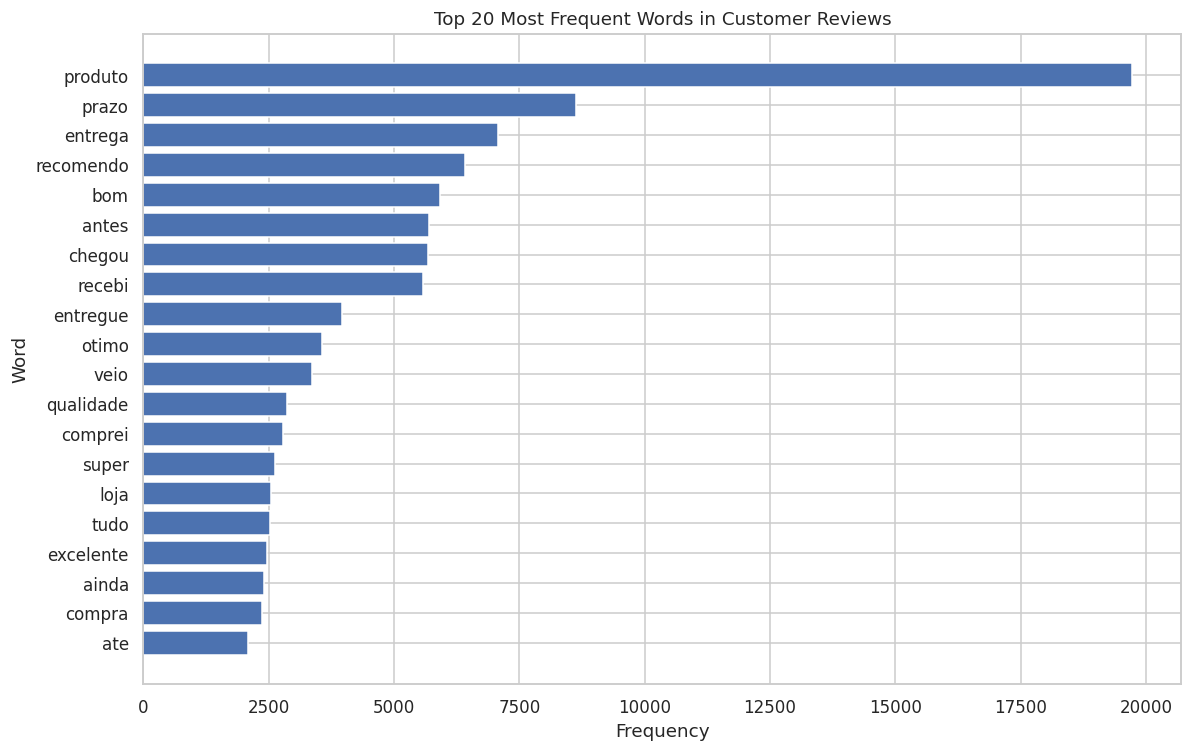

In [8]:
plt.figure(figsize=(11, 7))
plt.barh(top_words.sort_values("count")["word"], top_words.sort_values("count")["count"])
plt.title("Top 20 Most Frequent Words in Customer Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_top_20_words.png", bbox_inches="tight")
plt.show()

## 7. Word Clouds by Sentiment

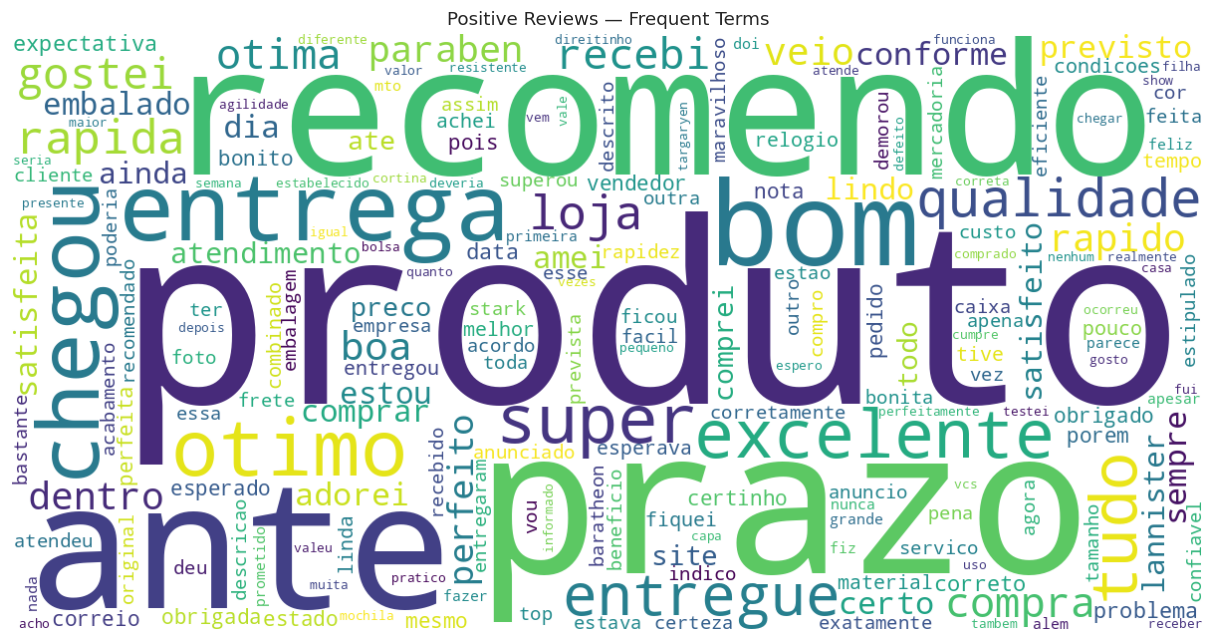

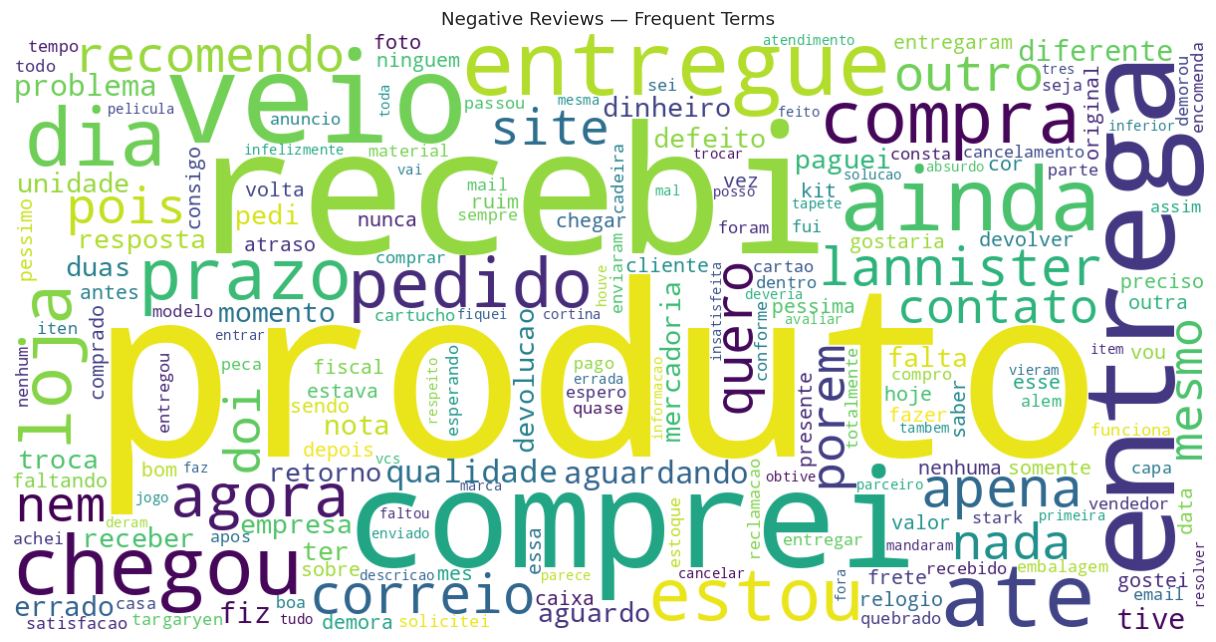

In [9]:
def make_wordcloud(text, title, filename):
    wc = WordCloud(width=1200, height=600, background_color="white", collocations=False).generate(text)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{filename}", bbox_inches="tight")
    plt.show()

positive_text = " ".join(text_df.loc[text_df["sentiment"] == "Positive", "clean_text"])
negative_text = " ".join(text_df.loc[text_df["sentiment"] == "Negative", "clean_text"])

make_wordcloud(positive_text, "Positive Reviews — Frequent Terms", "03_positive_wordcloud.png")
make_wordcloud(negative_text, "Negative Reviews — Frequent Terms", "04_negative_wordcloud.png")

## 8. Sentiment Analysis

In [10]:
sentiment_counts = text_df["sentiment"].value_counts().reindex(["Negative", "Neutral", "Positive"]).fillna(0).astype(int)
sentiment_pct = (sentiment_counts / sentiment_counts.sum() * 100).round(2)
sentiment_summary = pd.DataFrame({"count": sentiment_counts, "percentage": sentiment_pct})
sentiment_summary

,count,percentage
sentiment,,
Negative,10965,25.96
Neutral,3605,8.54
Positive,27664,65.50


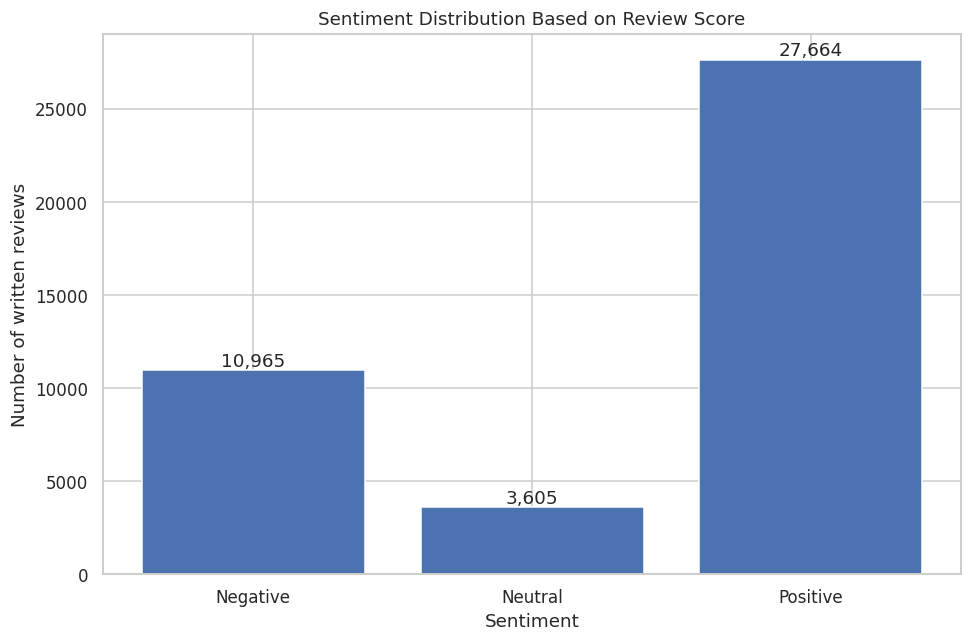

In [11]:
plt.figure(figsize=(9, 6))
plt.bar(sentiment_summary.index, sentiment_summary["count"].values)
plt.title("Sentiment Distribution Based on Review Score")
plt.xlabel("Sentiment")
plt.ylabel("Number of written reviews")
for i, value in enumerate(sentiment_summary["count"]):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_sentiment_distribution.png", bbox_inches="tight")
plt.show()

### Sentiment interpretation

The sentiment labels are derived from the customer's numeric rating: scores 1–2 are treated as negative, 3 as neutral, and 4–5 as positive. This approach is reproducible and directly tied to the dataset, but it should not be described as a fully independent sentiment classifier.

## 9. Topic Modeling with LDA

In [12]:
# Use a bounded sample for efficient, reproducible topic modeling.
RANDOM_STATE = 42
TOPIC_SAMPLE_SIZE = min(10000, len(text_df))
topic_df = text_df.sample(TOPIC_SAMPLE_SIZE, random_state=RANDOM_STATE).copy()

vectorizer = CountVectorizer(
    max_df=0.90,
    min_df=10,
    max_features=5000,
    ngram_range=(1, 2)
)
dtm = vectorizer.fit_transform(topic_df["clean_text"])

N_TOPICS = 5
lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=RANDOM_STATE,
    learning_method="batch",
    max_iter=8
)
lda.fit(dtm)

feature_names = vectorizer.get_feature_names_out()

def display_topics(model, features, n_words=10):
    rows = []
    for topic_idx, topic in enumerate(model.components_, start=1):
        top_indices = topic.argsort()[-n_words:][::-1]
        rows.append({"topic": f"Topic {topic_idx}", "top_words": ", ".join(features[top_indices])})
    return pd.DataFrame(rows)

topic_table = display_topics(lda, feature_names, 10)
topic_table

,topic,top_words
0,Topic 1,"bom, produto, excelente, entregue, tudo, produ..."
1,Topic 2,"produto, recebi, veio, otimo, recebi produto, ..."
2,Topic 3,"chegou, produto, ate, entrega, compra, dia, pr..."
3,Topic 4,"prazo, produto, antes, recomendo, entrega, ant..."
4,Topic 5,"produto, comprei, boa, recebi, produtos, dois,..."


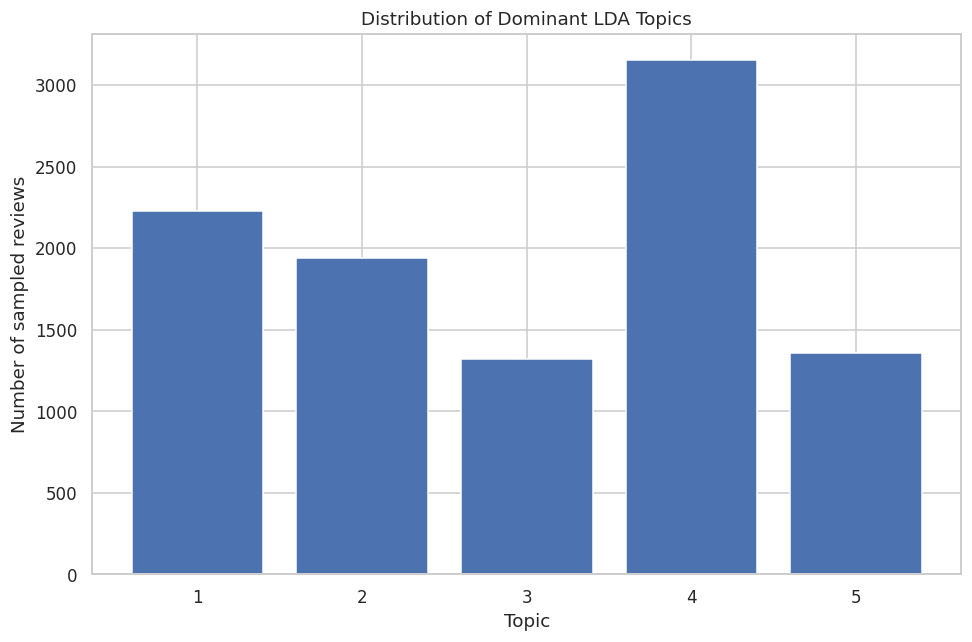

In [13]:
topic_distribution = lda.transform(dtm).argmax(axis=1) + 1
topic_counts = pd.Series(topic_distribution).value_counts().sort_index()

plt.figure(figsize=(9, 6))
plt.bar(topic_counts.index.astype(str), topic_counts.values)
plt.title("Distribution of Dominant LDA Topics")
plt.xlabel("Topic")
plt.ylabel("Number of sampled reviews")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/06_topic_distribution.png", bbox_inches="tight")
plt.show()

## 10. Topic-Level Sentiment View

In [14]:
topic_df["dominant_topic"] = topic_distribution
topic_sentiment = pd.crosstab(topic_df["dominant_topic"], topic_df["sentiment"], normalize="index").reindex(columns=["Negative", "Neutral", "Positive"]).fillna(0) * 100
topic_sentiment.round(2)

sentiment,Negative,Neutral,Positive
dominant_topic,,,
1,8.30,7.62,84.08
2,51.83,12.60,35.57
3,51.06,12.33,36.61
4,2.60,3.20,94.20
5,41.18,14.91,43.91


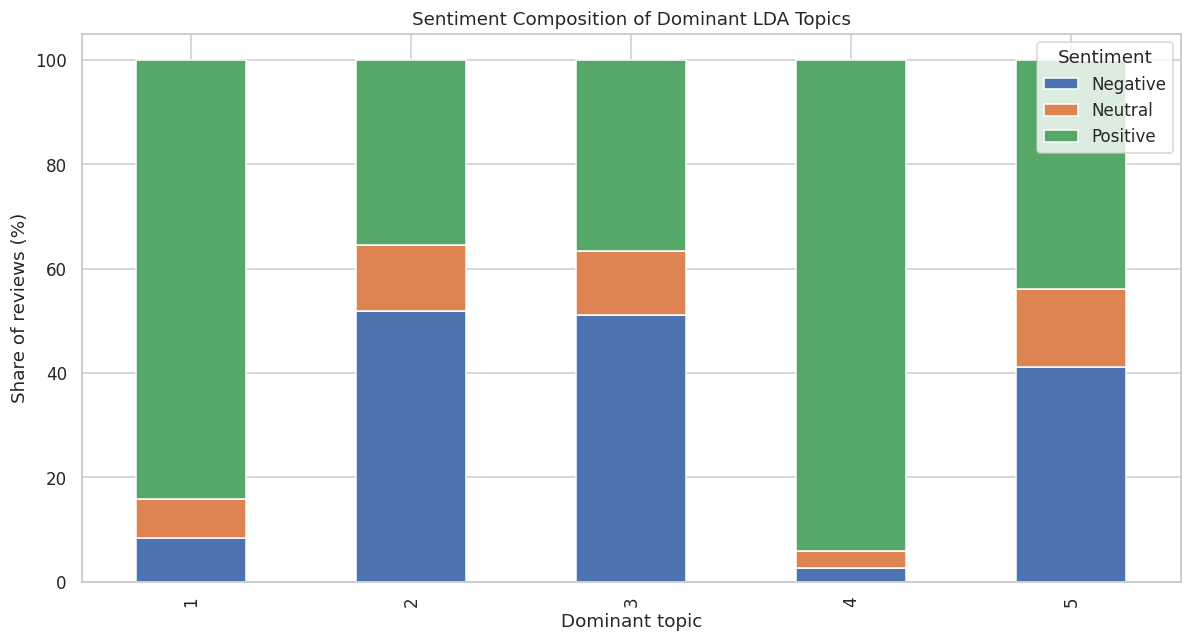

In [15]:
topic_sentiment.plot(kind="bar", stacked=True, figsize=(11, 6))
plt.title("Sentiment Composition of Dominant LDA Topics")
plt.xlabel("Dominant topic")
plt.ylabel("Share of reviews (%)")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/07_topic_sentiment.png", bbox_inches="tight")
plt.show()

## 11. Additional Review-Length Analysis

In [16]:
length_by_sentiment = text_df.groupby("sentiment")["token_count"].agg(["count", "mean", "median"]).reindex(["Negative", "Neutral", "Positive"]).round(2)
length_by_sentiment

,count,mean,median
sentiment,,,
Negative,10965,10.12,9.0
Neutral,3605,8.55,7.0
Positive,27664,5.82,5.0


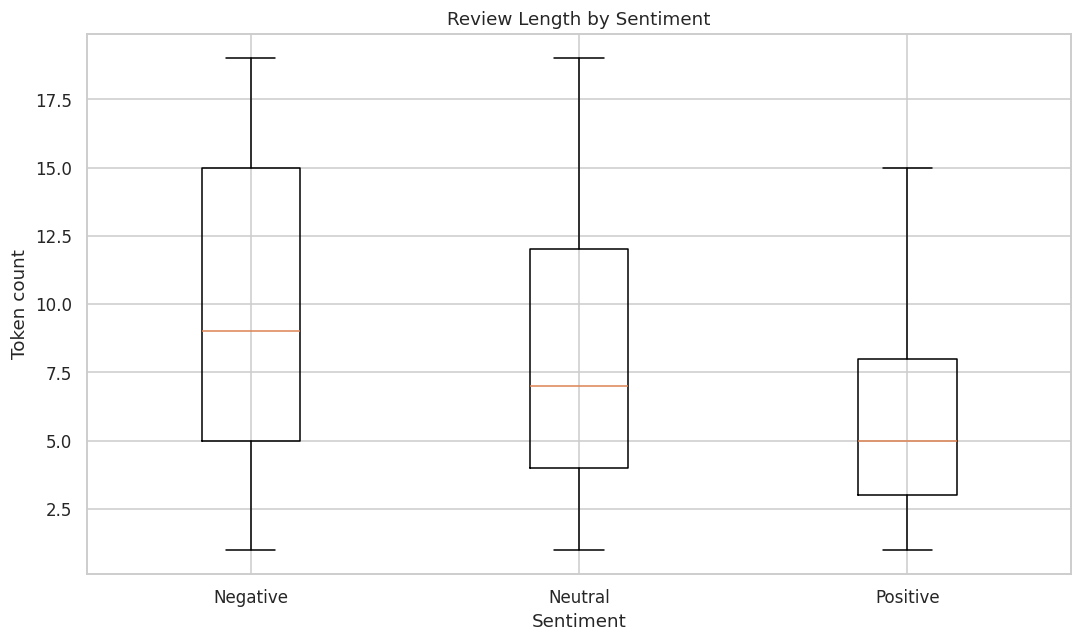

In [17]:
plt.figure(figsize=(10, 6))
plt.boxplot([text_df.loc[text_df["sentiment"] == s, "token_count"].clip(upper=text_df["token_count"].quantile(0.95)) for s in ["Negative", "Neutral", "Positive"]], labels=["Negative", "Neutral", "Positive"], showfliers=False)
plt.title("Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Token count")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/08_review_length_by_sentiment.png", bbox_inches="tight")
plt.show()

## 12. Key Findings

In [18]:
# Generate a compact, data-backed summary from executed results.
top_word = top_words.iloc[0]
positive_share = sentiment_summary.loc["Positive", "percentage"]
negative_share = sentiment_summary.loc["Negative", "percentage"]
neutral_share = sentiment_summary.loc["Neutral", "percentage"]
print(f"1. {len(reviews):,} total review records are available; {len(text_df):,} contain usable written text.")
print(f"2. Written-review sentiment proxy: {positive_share:.2f}% positive, {neutral_share:.2f}% neutral, {negative_share:.2f}% negative.")
print(f"3. Most frequent cleaned word: '{top_word['word']}' ({top_word['count']:,} occurrences).")
print(f"4. LDA was trained on {TOPIC_SAMPLE_SIZE:,} written reviews and produced {N_TOPICS} topics.")
print("5. Topic keywords above can be manually interpreted into business themes such as delivery, product quality, service, or purchasing experience.")

1. 99,224 total review records are available; 42,234 contain usable written text.
2. Written-review sentiment proxy: 65.50% positive, 8.54% neutral, 25.96% negative.
3. Most frequent cleaned word: 'produto' (19,720 occurrences).
4. LDA was trained on 10,000 written reviews and produced 5 topics.
5. Topic keywords above can be manually interpreted into business themes such as delivery, product quality, service, or purchasing experience.


## 13. Conclusion

This project demonstrates an end-to-end NLP workflow on real customer-review data: data exploration, text cleaning, tokenization, Portuguese stopword removal, word-frequency analysis, rating-based sentiment analysis, LDA topic modeling, and visualization. The analysis can help identify recurring customer concerns and positive themes in e-commerce reviews.

### Limitations
1. Reviews without written comments cannot contribute to text analysis.
2. Sentiment labels are derived from review scores, so they measure rating sentiment rather than an independent NLP classifier.
3. LDA topics are statistical word groups and require human interpretation.
4. The dataset is historical and represents the source dataset's period and population, not current e-commerce behavior.

### Suggested future improvement
Train a Portuguese sentiment classifier using the review text and score-derived labels, then evaluate it with precision, recall, F1-score, and a confusion matrix.